# Wizualizacja wyników egzaminów studentów za pomocą powierzchni 3D i wykresów punktowych (PROC G3D)

## Streszczenie

Ten notatnik wykorzystuje **PROC G3D** do wizualizacji, jak dwa czynniki
interwencji dydaktycznej wspólnie kształtują wyniki studentów w kontekście
analityki edukacyjnej. Kompletna siatka czynnikowa napędza gładką
**powierzchnię** odpowiedzi przewidywanych wyników egzaminu w funkcji
tygodniowych godzin nauki (0 do 20) i wcześniejszej średniej GPA (0 do 4),
a syntetyczna kohorta 100 studentów jest przedstawiona jako panele
**punktowe 3D** podzielone według pasma osiągnięć.

Dopasowana powierzchnia wznosi się od przewidywanego wyniku bliskiego 26
przy zerowej liczbie godzin nauki do pułapu bliskiego 99, spłaszczając się,
gdy godziny nauki przekraczają w przybliżeniu 10 — jest to grzbiet malejących
przyrostów zakodowany w modelu. Panele studentów potwierdzają ten wzorzec na
poziomie indywidualnym: 20 studentów **Celujący** (każdy z wynikiem 85 lub
wyższym) znajduje się w rogu wysokiego GPA i wyższej liczby godzin nauki,
podczas gdy 33 studentów **Zagrożony** koncentruje się w obszarze niskiego
wysiłku i niskiego GPA. Widok przefiltrowany przez WHERE dla tego rogu
izoluje 35 studentów, dla których umiarkowany wzrost czasu nauki oferuje
największe korzyści krańcowe.


## Źródła danych

Wszystkie dane są generowane wewnętrznie za pomocą `call streaminit()` i
`rand()` — bez plików zewnętrznych ani dostępu do sieci.

**`score_grid`** — kompletna siatka czynnikowa napędzająca powierzchnię
odpowiedzi (jeden wiersz na komórkę godziny-nauki x wcześniejsze-GPA, 99
wierszy).

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `study_hours` | Num | Tygodniowe godziny samodzielnej nauki, 0 do 20 co 2 (oś X) |
| `prior_gpa` | Num | Wcześniejsza średnia GPA w skali 0–4, 0 do 4 co 0,5 (oś Y) |
| `pred_score` | Num | Modelowany wynik egzaminu końcowego 0–100 z nasycającego modelu odpowiedzi (oś Z) |

**`students`** — syntetyczna kohorta indywidualnych studentów do wykresu
punktowego (100 wierszy).

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `student_id` | Num | Sekwencyjny identyfikator studenta |
| `study_hours` | Num | Obserwowane tygodniowe godziny nauki (oś X) |
| `prior_gpa` | Num | Obserwowana wcześniejsza średnia GPA (oś Y) |
| `exam_score` | Num | Obserwowany wynik egzaminu końcowego 0–100 (oś Z) |
| `cohort` | Char | Kohorta rekrutacyjna, `Jesień` lub `Wiosna` |
| `band` | Char | Pasmo osiągnięć: `Celujący` (≥85), `Zaliczony` (65–84), `Zagrożony` (<65) |

Siatka jest celowo rozmiarowana na 99 komórek, aby obejmowała pełny zakres
0–20 godzin nauki i 0–4 GPA, pozostając w granicach limitu 100 obserwacji
tego środowiska; siatka 11 x 9 utrzymuje gładkość powierzchni bez ucinania
żadnej osi.


# Wizualizacja wyników egzaminów studentów za pomocą PROC G3D

Badacze edukacji często chcą zrozumieć, jak dwa modyfikowalne czynniki
wspólnie kształtują wynik. Tutaj pytamy: *jak tygodniowe godziny nauki i
wcześniejsza średnia GPA studenta łączą się, aby kształtować wynik
egzaminu końcowego?*

Wykres dwuwymiarowy nie może pokazać powierzchni interakcji. **PROC G3D**
rysuje prawdziwe wykresy trójwymiarowe ze zmiennych w notacji `y*x=z`,
gdzie X i Y rozpościerają się na płaszczyźnie poziomej, a Z wznosi się
pionowo. Wykorzystujemy dwie jego możliwości:

- **PLOT** — ciągła **powierzchnia** odpowiedzi na kompletnej siatce dwóch
  predyktorów.
- **SCATTER** — indywidualni studenci przedstawieni jako symbole 3D.
  Rysujemy jeden panel na pasmo osiągnięć, każdy z własnym kolorem i
  kształtem znacznika, aby trzy poziomy wyniku były łatwe do porównania.

Wszystko poniżej działa na syntetycznych danych generowanych wewnętrznie,
więc notatnik jest w pełni samowystarczalny.


## Krok 1 — Wygeneruj siatkę powierzchni odpowiedzi

Wykres powierzchni G3D wymaga stosunkowo kompletnej siatki: wymaga
niebrakujących wartości Z dla co najmniej połowy komórek X-Y. Gwarantujemy
*kompletną* siatkę, zagnieżdżając dwie pętle `DO` po `study_hours` (0 do 20
co 2) i `prior_gpa` (0 do 4 co 0,5) — siatka 11 x 9 z 99 komórkami, która
w pełni obejmuje obie osie.

Przewidywany wynik podąża za prawdopodobnym nasycającym modelem: zwroty z
nauki maleją przy dużej liczbie godzin, wcześniejsze GPA wnosi wkład
w przybliżeniu liniowy, a te dwa czynniki wchodzą w interakcję (silniejszy
student przekłada czas nauki na punkty efektywniej). Mały odtwarzalny
szum z `rand('NORMAL')` sprawia, że powierzchnia nie wygląda idealnie
analitycznie. `call streaminit()` ustala ziarno, więc siatka jest
odtwarzalna.


In [1]:
DANE score_grid;
   CALL streaminit(20260531);
   POWTÓRZ study_hours = 0 TO 20 WEDŁUG 2;     /* 11 wartości: pełny zakres 0-20 */
      POWTÓRZ prior_gpa = 0 TO 4 WEDŁUG 0.5;   /* 9 wartości  -> 99 komórek siatki */
         /* nasycający zwrot z godzin nauki */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* wcześniejsze osiągnięcia i człon interakcji */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         JEŚLI pred_score > 100 WTEDY pred_score = 100;
         JEŚLI pred_score < 0   WTEDY pred_score = 0;
         WYJŚCIE;
      KONIEC;
   KONIEC;
   ZACHOWAJ study_hours prior_gpa pred_score;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=score_grid n MIN mean MAX maxdec=1;
   ZMIENNA study_hours prior_gpa pred_score;
WYKONAJ;


                                                  The MEANS Procedure

 Variable           N     Minimum        Mean     Maximum
 --------------------------------------------------------
 study_hours       99         0.0        10.0        20.0
 prior_gpa         99         0.0         2.0         4.0
 pred_score        99        25.7        70.0        98.7
 --------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 2 — Narysuj bazową powierzchnię odpowiedzi

Mając kompletną siatkę, najprostsze wywołanie rysuje powierzchnię przy
użyciu domyślnych ustawień procedury. Składnia `PLOT y*x=z` mapuje
`prior_gpa` na oś Y, `study_hours` na oś X, a przewidywany wynik na
pionową oś Z.

Etykietujemy osie instrukcją `LABEL` oraz ustawiamy tytuły i przypis
globalnymi instrukcjami `TITLE`/`FOOTNOTE`, aby wykres czytał się
przejrzyście.


                                 Powierzchnia przewidywanego wyniku egzaminu końcowego                                  
                                  Wpływ tygodniowych godzin nauki i wcześniejszego GPA                                  

PROC G3D Output
Data: score_grid

Variables: Tygodniowe godziny nauki, Wcześniejsze GPA, Przewidywany wynik egzaminu

Tygodniowe godziny nauki   Wcześniejsze GPA  Przewidywany wynik egzaminu
------------------------  -----------------  ---------------------------
                       0                  0                25.7031536911
                       0                0.5                28.9516502743
                       0                  1                32.3400787822
                       0                1.5                36.8265757618
                       0                  2                40.7806886968
                       0                2.5                  42.61364606
                       0                  3            


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Powierzchnia przewidywanego wyniku egzaminu końcowego.
NOTE: Option TITLE2 changed to Wpływ tygodniowych godzin nauki i wcześniejszego GPA.
NOTE: Option FOOTNOTE changed to Syntetyczne dane analityki edukacyjnej .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


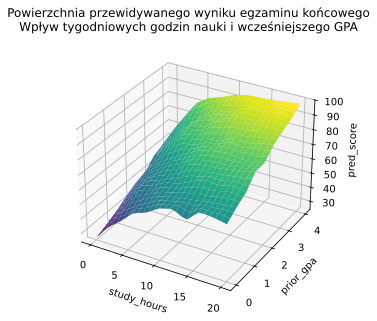

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TYTUŁ 'Powierzchnia przewidywanego wyniku egzaminu końcowego';
title2 'Wpływ tygodniowych godzin nauki i wcześniejszego GPA';
footnote j=r 'Syntetyczne dane analityki edukacyjnej ';

PROCEDURA g3d DANE=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         pred_score  = 'Przewidywany wynik egzaminu';
WYKONAJ;
QUIT;


## Krok 3 — Dopracuj powierzchnię opcjami widoku i osi

Kilka opcji sprawia, że powierzchnia jest znacznie bardziej czytelna:

- **ROTATE=** i **TILT=** ustawiają kąt widzenia (stopnie wokół osi Z oraz
  pochylenie w stronę widza).
- **XYTYPE=2** rysuje linie powierzchni równoległe do osi Y, podkreślając,
  jak wynik rośnie wraz z godzinami nauki.
- **SIDE** dodaje ścianę boczną dla solidnego, rzeźbionego wyglądu.
- **GRID** dodaje linie odniesienia przy głównych znacznikach skali.
- **ZMIN=/ZMAX=** oraz rodzina **ZTICKNUM=** ustalają oś wyniku na pełny
  zakres 0–100, aby powierzchnia nie była wizualnie przesadzona, natomiast
  **XTICKNUM=/YTICKNUM=** kontrolują znaczniki płaszczyzny podłogi.
- **NAME=** i **DESCRIPTION=** etykietują wykres w katalogu wyjściowym.


                            Powierzchnia przewidywanego wyniku egzaminu (widok stylizowany)                             
                                     Obrócona, pochylona i przeskalowana na osiach                                      

PROC G3D Output
Data: score_grid

Variables: Tygodniowe godziny nauki, Wcześniejsze GPA, Przewidywany wynik egzaminu

Tygodniowe godziny nauki   Wcześniejsze GPA  Przewidywany wynik egzaminu
------------------------  -----------------  ---------------------------
                       0                  0                25.7031536911
                       0                0.5                28.9516502743
                       0                  1                32.3400787822
                       0                1.5                36.8265757618
                       0                  2                40.7806886968
                       0                2.5                  42.61364606
                       0                  3            


NOTE: Option TITLE changed to Powierzchnia przewidywanego wyniku egzaminu (widok stylizowany).
NOTE: Option TITLE2 changed to Obrócona, pochylona i przeskalowana na osiach.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


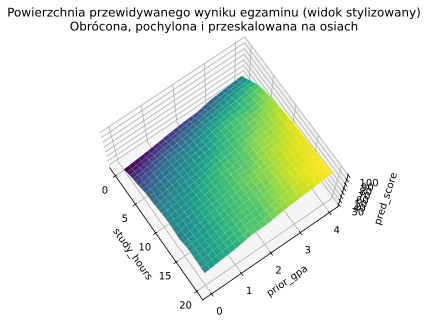

In [3]:
TYTUŁ 'Powierzchnia przewidywanego wyniku egzaminu (widok stylizowany)';
title2 'Obrócona, pochylona i przeskalowana na osiach';

PROCEDURA g3d DANE=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Stylizowana powierzchnia odpowiedzi wyniku egzaminu";
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         pred_score  = 'Przewidywany wynik egzaminu';
WYKONAJ;
QUIT;


## Krok 4 — Porównaj powierzchnię z kilku kątów widzenia

Ponieważ powierzchnia 3D może ukrywać strukturę za własnymi szczytami,
pomaga wyrenderować tę samą powierzchnię z więcej niż jednej rotacji. Tu
wydajemy trzy kroki PROC G3D, które dzielą stałe pochylenie, ale zmieniają
kąt **ROTATE=** przez 30, 90 i 150 stopni, aby grzbiet można było obejrzeć
z przodu, z boku i z tyłu.


                                                Powierzchnia odpowiedzi                                                 
                                            ROTATE = 30 przy ustalonym TILT                                             

PROC G3D Output
Data: score_grid

Variables: Tygodniowe godziny nauki, Wcześniejsze GPA, Przewidywany wynik egzaminu

Tygodniowe godziny nauki   Wcześniejsze GPA  Przewidywany wynik egzaminu
------------------------  -----------------  ---------------------------
                       0                  0                25.7031536911
                       0                0.5                28.9516502743
                       0                  1                32.3400787822
                       0                1.5                36.8265757618
                       0                  2                40.7806886968
                       0                2.5                  42.61364606
                       0                  3            


NOTE: Option TITLE changed to Powierzchnia odpowiedzi.
NOTE: Option TITLE2 changed to ROTATE = 30 przy ustalonym TILT.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Powierzchnia odpowiedzi.
NOTE: Option TITLE2 changed to ROTATE = 90 przy ustalonym TILT.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Powierzchnia odpowiedzi.
NOTE: Option TITLE2 changed to ROTATE = 150 przy ustalonym TILT.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


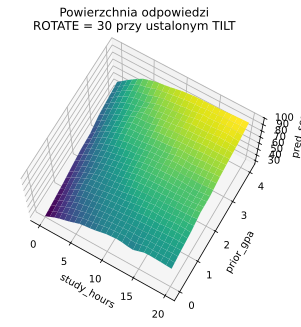

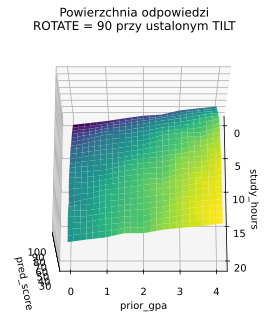

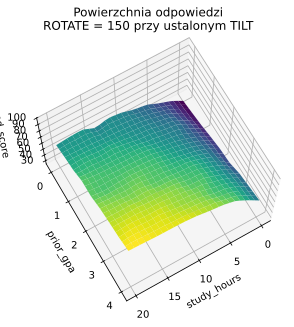

In [4]:
%macro angle(deg);
   TYTUŁ 'Powierzchnia odpowiedzi';
   title2 "ROTATE = &deg przy ustalonym TILT";
   PROCEDURA g3d DANE=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ETYKIETA study_hours = 'Tygodniowe godziny nauki'
            prior_gpa   = 'Wcześniejsze GPA'
            pred_score  = 'Przewidywany wynik egzaminu';
   WYKONAJ;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Krok 5 — Wygeneruj syntetyczną kohortę studentów

Powierzchnia jest modelem; prawdziwi studenci rozpraszają się wokół niej.
Symulujemy teraz 100 indywidualnych studentów pochodzących z dwóch kohort
rekrutacyjnych (`Jesień`, `Wiosna`). Każdy student ma obserwowane godziny
nauki, wcześniejsze GPA i zaszumiony zrealizowany wynik egzaminu
wygenerowany z tej samej logiki odpowiedzi plus większą indywidualną
zmienność.

Następnie wyprowadzamy pasmo osiągnięć **band** z wyniku egzaminu:
`Celujący` (85 lub więcej), `Zaliczony` (65 do 84) i `Zagrożony` (poniżej
65). Poniższa tabela krzyżowa PROC FREQ pokazuje, jak pasma rozkładają się
w obu kohortach. `rand('UNIFORM')` i `rand('NORMAL')` dostarczają losowości;
ziarno utrzymuje odtwarzalność.


                                                Powierzchnia odpowiedzi                                                 
                                            ROTATE = 150 przy ustalonym TILT                                            

                                                   The FREQ Procedure

                                   Cumulative
Pasmo osiągnięć       Frequency    Frequency
------------------------------------------------
Celujący                     20           20
Zagrożony                    33           53
Zaliczony                    47          100

Table of Kohorta by Pasmo osiągnięć

Kohorta |  Celujący | Zagrożony | Zaliczony |      Total
--------+-----------+-----------+-----------+-----------
Jesień  |         6 |        15 |        20 |         41
--------+-----------+-----------+-----------+-----------
Wiosna  |        14 |        18 |        27 |         59
--------+-----------+-----------+-----------+-----------
Total   |        20 |        33


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


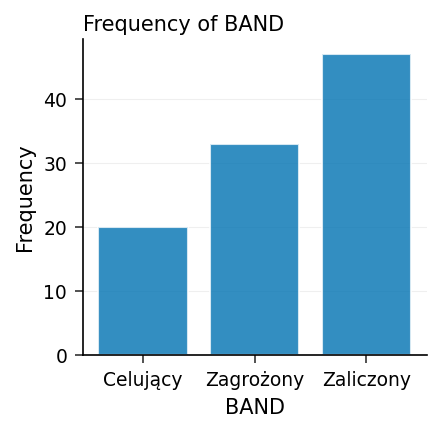

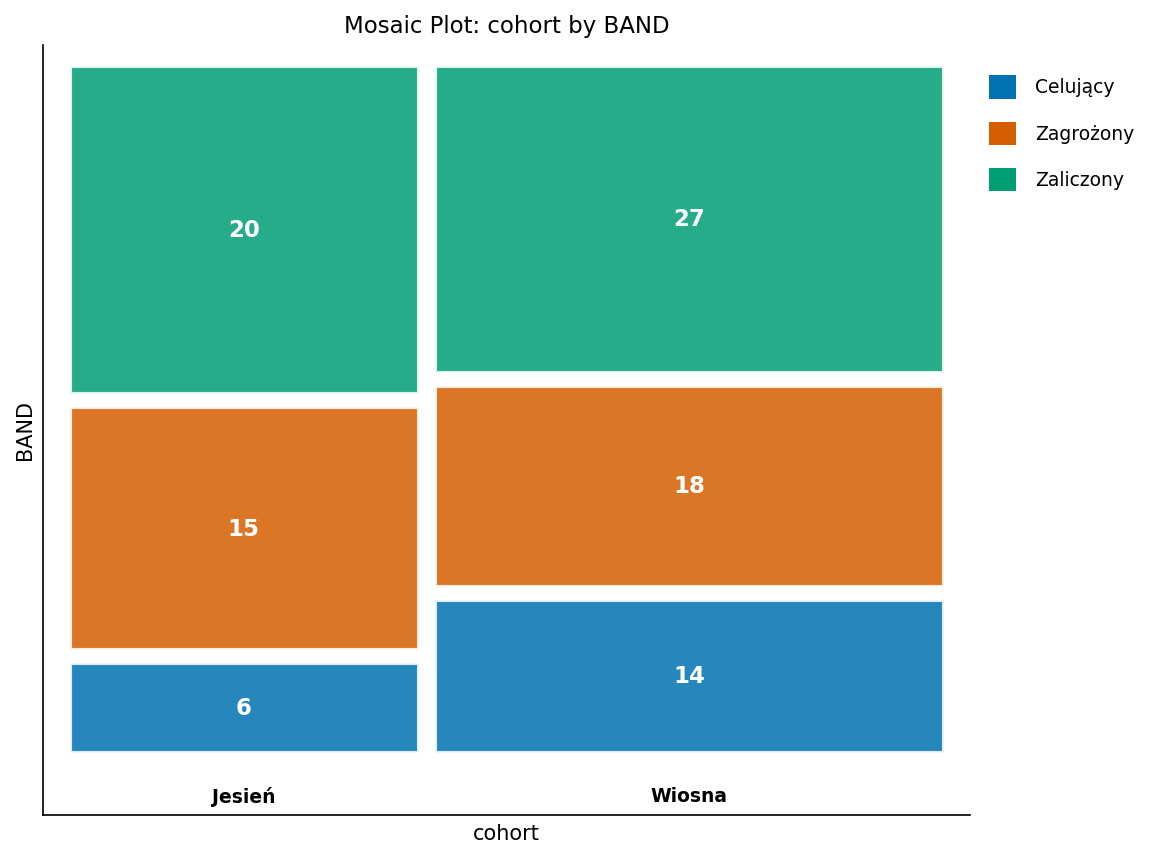

In [5]:
DANE students;
   CALL streaminit(99001);
   DŁUGOŚĆ cohort $8 BAND $12;
   POWTÓRZ student_id = 1 TO 100;
      JEŚLI rand('UNIFORM') < 0.5 WTEDY cohort = 'Jesień';
      PRZECIWNIE cohort = 'Wiosna';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      JEŚLI exam_score > 100 WTEDY exam_score = 100;
      JEŚLI exam_score < 0   WTEDY exam_score = 0;

      JEŚLI exam_score >= 85 WTEDY BAND = 'Celujący';
      PRZECIWNIE JEŚLI exam_score >= 65 WTEDY BAND = 'Zaliczony';
      PRZECIWNIE BAND = 'Zagrożony';

      WYJŚCIE;
   KONIEC;
   ZACHOWAJ student_id cohort study_hours prior_gpa exam_score BAND;
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   ETYKIETA BAND="Pasmo osiągnięć" cohort="Kohorta";
WYKONAJ;


## Krok 6 — Narysuj studentów jako panele punktowe 3D według pasma
osiągnięć

Instrukcja **SCATTER** umieszcza każdego studenta jako symbol 3D. Aby
trzy poziomy osiągnięć były łatwe do odczytania, rysujemy jeden panel na
pasmo, każdy przefiltrowany za pomocą **WHERE** i z własnym dosłownym
**COLOR=** i **SHAPE=**: zielone diamenty (`SHAPE=diamond`) dla
*Celujący*, niebieskie znaczniki (`SHAPE=club`) dla *Zaliczony* i
czerwone znaczniki (`SHAPE=spade`) dla *Zagrożony*. **SIZE=** powiększa
znaczniki, **GRID** dodaje linie odniesienia podłogi, **NONEEDLE** usuwa
pionowe linie opuszczające, a **ZMIN=/ZMAX=** utrzymują każdy panel na tej
samej osi wyniku 0–100, aby trzy widoki były bezpośrednio porównywalne.

Każde pasmo otrzymuje własny krok PROC G3D, aby jego filtr WHERE
stosował się czysto, a styl znacznika był jednoznaczny.


                                                   Studenci Celujący                                                    
                                              Wynik egzaminu 85 i powyżej                                               

PROC G3D Output
Data: students

Variables: student_id, cohort, Tygodniowe godziny nauki, Wcześniejsze GPA, Wynik egzaminu końcowego, BAND

student_id      cohort  Tygodniowe godziny nauki   Wcześniejsze GPA   Wynik egzaminu końcowego        BAND
----------  ----------  ------------------------  -----------------  -------------------------  ----------
         2      Wiosna             19.2134883194       2.6467742616              90.3663886999    Celujący
         5      Wiosna             15.5520919174       2.7102003827              94.9419468332    Celujący
        10      Wiosna             14.2302640951       3.8791496428                        100    Celujący
        17      Wiosna             13.7403346635       2.7462821708              89


NOTE: Option FOOTNOTE changed to Z kohorty 100 syntetycznych studentów .
NOTE: Option TITLE changed to Studenci Celujący.
NOTE: Option TITLE2 changed to Wynik egzaminu 85 i powyżej.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Studenci Zaliczeni.
NOTE: Option TITLE2 changed to Wynik egzaminu 65 do 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Studenci Zagrożeni.
NOTE: Option TITLE2 changed to Wynik egzaminu poniżej 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


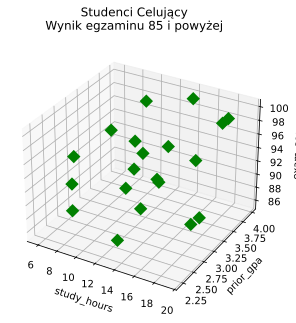

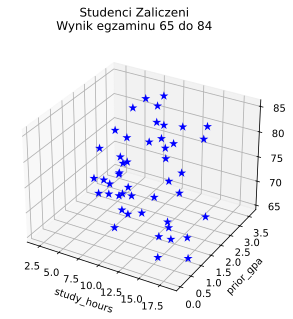

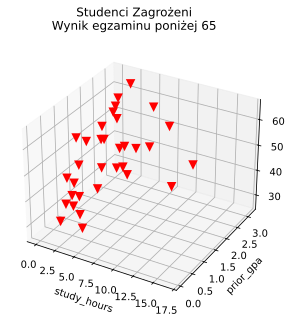

In [6]:
footnote j=r 'Z kohorty 100 syntetycznych studentów ';

/* Celujący (exam_score >= 85): zielone diamenty */
TYTUŁ 'Studenci Celujący';
title2 'Wynik egzaminu 85 i powyżej';
PROCEDURA g3d DANE=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Studenci Celujący";
   GDZIE BAND = 'Celujący';
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         exam_score  = 'Wynik egzaminu końcowego';
WYKONAJ;
QUIT;

/* Zaliczony (65 <= exam_score < 85): niebieskie kluby */
TYTUŁ 'Studenci Zaliczeni';
title2 'Wynik egzaminu 65 do 84';
PROCEDURA g3d DANE=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Studenci Zaliczeni";
   GDZIE BAND = 'Zaliczony';
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         exam_score  = 'Wynik egzaminu końcowego';
WYKONAJ;
QUIT;

/* Zagrożony (exam_score < 65): czerwone piki */
TYTUŁ 'Studenci Zagrożeni';
title2 'Wynik egzaminu poniżej 65';
PROCEDURA g3d DANE=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Studenci zagrożeni";
   GDZIE BAND = 'Zagrożony';
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         exam_score  = 'Wynik egzaminu końcowego';
WYKONAJ;
QUIT;


## Krok 7 — Osobne wykresy punktowe dla każdej kohorty rekrutacyjnej
(grupa BY)

Liderzy programów często potrzebują tego samego widoku podzielonego według
kohorty. Instrukcja **BY** tworzy jeden wykres punktowy na kohortę. G3D
oczekuje, że dane grupy BY są posortowane, więc najpierw sortujemy za
pomocą PROC SORT. Każda kohorta otrzymuje wtedy własny oznaczony wykres
punktowy 3D na wspólnej osi wyniku 0–100, dzięki czemu rozkłady Jesień i
Wiosna są łatwe do porównania obok siebie.


                                      Wyniki egzaminu według kohorty rekrutacyjnej                                      
                                  Jeden wykres punktowy 3D na kohortę (Jesień, Wiosna)                                  

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Tygodniowe godziny nauki, Wcześniejsze GPA, Wynik egzaminu końcowego, BAND

student_id      cohort  Tygodniowe godziny nauki   Wcześniejsze GPA   Wynik egzaminu końcowego        BAND
----------  ----------  ------------------------  -----------------  -------------------------  ----------
        52      Jesień             15.2586640362       0.4602308374              55.5186804916   Zagrożony
        13      Jesień              5.8493366471       1.8449001873              70.6084324429   Zaliczony
        15      Jesień              5.5070892672       1.4478111608              70.0069314398   Zaliczony
        22      Jesień              0.0365105382       1.3187236247         


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Wyniki egzaminu według kohorty rekrutacyjnej.
NOTE: Option TITLE2 changed to Jeden wykres punktowy 3D na kohortę (Jesień, Wiosna).
NOTE: Option FOOTNOTE changed to Jeden panel na kohortę .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


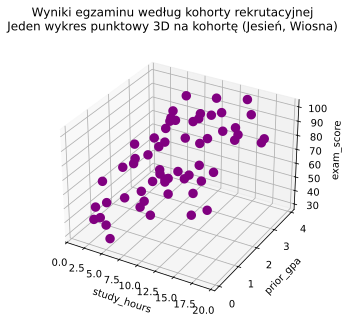

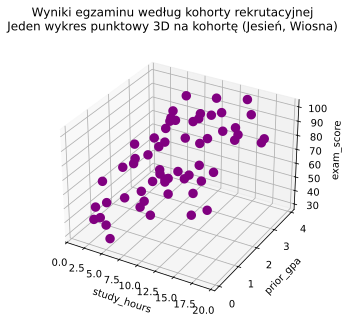

In [7]:
PROCEDURA SORTUJ DANE=students out=students_sorted;
   WEDŁUG cohort;
WYKONAJ;

TYTUŁ 'Wyniki egzaminu według kohorty rekrutacyjnej';
title2 'Jeden wykres punktowy 3D na kohortę (Jesień, Wiosna)';
footnote j=r 'Jeden panel na kohortę ';

PROCEDURA g3d DANE=students_sorted;
   WEDŁUG cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         exam_score  = 'Wynik egzaminu końcowego';
WYKONAJ;
QUIT;


## Krok 8 — Skup się na regionie zagrożenia za pomocą WHERE

Do planowania interwencji najbardziej praktyczny widok to dolny lewy róg
powierzchni: studenci z zarówno umiarkowanym czasem nauki (8 godzin lub
mniej), jak i niższym wcześniejszym GPA (2,5 lub mniej). Instrukcja
**WHERE** ogranicza wykres punktowy do tego regionu przed rysowaniem.
Listing pokazuje, że ten róg obejmuje 35 ze 100 studentów — 22 z nich to
już *Zagrożony* — więc doradcy mogą zobaczyć dokładnie, którzy zmagający
się studenci znajdują się najdalej poniżej oczekiwań.


                              Fokus interwencji: studenci o niższym wysiłku i niższym GPA                               
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Tygodniowe godziny nauki, Wcześniejsze GPA, Wynik egzaminu końcowego, BAND

student_id      cohort  Tygodniowe godziny nauki   Wcześniejsze GPA   Wynik egzaminu końcowego        BAND
----------  ----------  ------------------------  -----------------  -------------------------  ----------
         1      Jesień              4.9780700766        1.072086769               59.409228777   Zagrożony
         7      Wiosna              7.9015823058       1.6623636789              66.9055021729   Zaliczony
         9      Wiosna              2.5008494545       0.3621033759              48.1183184446   Zagrożony
        11      Wiosna              7.1907276895       2.1821388818               7


NOTE: Option TITLE changed to Fokus interwencji: studenci o niższym wysiłku i niższym GPA.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Linie pionowe łączą każdy punkt z płaszczyzną godzin nauki i GPA .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


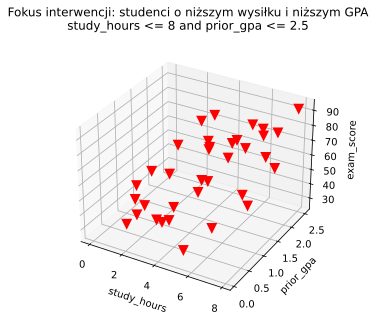

In [8]:
TYTUŁ 'Fokus interwencji: studenci o niższym wysiłku i niższym GPA';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Linie pionowe łączą każdy punkt z płaszczyzną godzin nauki i GPA ';

PROCEDURA g3d DANE=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   GDZIE study_hours <= 8 AND prior_gpa <= 2.5;
   ETYKIETA study_hours = 'Tygodniowe godziny nauki'
         prior_gpa   = 'Wcześniejsze GPA'
         exam_score  = 'Wynik egzaminu końcowego';
WYKONAJ;
QUIT;


## Interpretacja wyników

**Powierzchnia odpowiedzi** (kroki 2–4) pokazuje wyraźny nasycający
grzbiet. W obrębie siatki 99 komórek przewidywany wynik przebiega od około
26 (zero godzin nauki, zero GPA) do około 99 (róg wysokich godzin,
wysokiego GPA), ze średnią dla całej siatki bliską 70. Czytając wzdłuż osi
godzin nauki, wyniki rosną stromo od 0 do w przybliżeniu 10 godzin, a
następnie spłaszczają się, gdy dodatkowe godziny przynoszą malejące
korzyści; czytając wzdłuż osi GPA, wcześniejsze osiągnięcia przesuwają
całą powierzchnię w górę. Człon interakcji sprawia, że korzyść z godzin
nauki jest nieco stromsza dla silniejszych studentów, dlatego powierzchnia
przechyla się w stronę swojego dalekiego rogu, zamiast wznosić się jako
płaska płaszczyzna.

**Panele studentów** (kroki 6–7) potwierdzają, że model utrzymuje się dla
jednostek. Kohorta 100 studentów dzieli się na 20 *Celujący*, 47
*Zaliczony* i 33 *Zagrożony*. W panelach pasm, 20 zielonych diamentów
*Celujący* — każdy z wynikiem 85 lub wyższym — znajduje się przy
wcześniejszym GPA 2,2 lub wyższym i co najmniej około 6 tygodniowych
godzinach nauki, skupionych w prawym górnym rogu płaszczyzny podłogi. 33
czerwone znaczniki *Zagrożony* koncentrują się w obszarze niskiego
wysiłku i niskiego GPA, dokładnie w dolinie powierzchni. Podział według
kohorty pokazuje, że rozkłady Jesień (41 studentów) i Wiosna (59
studentów) są ogólnie podobne, co sugeruje, że wyniki są napędzane przez
te dwa czynniki, a nie przez moment rekrutacji.

**Widok przefiltrowany przez WHERE** (krok 8) izoluje populację
interwencji: 35 studentów z 8 lub mniej godzinami nauki i GPA 2,5 lub
niższym. Dwudziestu dwóch jest już *Zagrożony*, a tylko jeden osiąga
*Celujący*. W tym rogu zrealizowane wyniki nadal wyraźnie rosną wraz z
godzinami nauki — konkretny, wizualny argument, że umiarkowany wzrost
uporządkowanego czasu nauki oferuje największe korzyści krańcowe
dokładnie tam, gdzie są najbardziej potrzebne.

Razem wzięte, PROC G3D zamienia model interakcji dwóch czynników w
intuicyjny, gotowy do decyzji obraz dla programu edukacyjnego: gdzie leży
pułap wyniku, kto nie osiąga go, i gdzie wysiłek coachingowy przyniesie
największe korzyści.

> **Uwaga dotycząca implementacji.** SAS/GRAPH pozwala także pojedynczej
> instrukcji SCATTER kolorować i kształtować każdy znacznik na podstawie
> zmiennych na poziomie obserwacji (`COLOR=<charvar>`, `SHAPE=<charvar>`).
> Ta forma na poziomie obserwacji nie renderuje się jeszcze w tym silniku,
> więc ten notatnik rysuje zamiast tego jeden panel o dosłownym kolorze na
> pasmo — równoważną, w pełni działającą prezentację. Ta luka jest śledzona
> przez zbankowany test regresyjny
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
